In [ ]:
!git clone https://github.com/Ignas12345/Magistras_pagalbines_funkcijos.git

import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import fdrcorrection

from Magistras_pagalbines_funkcijos.pagalbines_funkcijos import *

Cloning into 'Magistras_pagalbines_funkcijos'...
remote: Enumerating objects: 96, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 96 (delta 34), reused 7 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (96/96), 43.29 KiB | 1.24 MiB/s, done.
Resolving deltas: 100% (34/34), done.


Čia bandoma atkartoti TCGA tyrimo 4 paveiksliuką - daug kas gaunasi panašiai, tik su Teratoma skirtingai (p-value kitokie ir gal reiktų pakeisti kodą, taip, kad neišfiltruojam silpniau išreikštų miRNR, bet juos kažkaip paryškinam arba tiesiog paliekam jeigu vidurkis bent vienoje iš grupių siekia 50 RPM).

In [ ]:
folder_1 = 'https://raw.githubusercontent.com/Ignas12345/Magistras_knygutes_ir_duomenys/refs/heads/main/duomenys/TCGA_TGCT/'
url_miRNR_normalized_isoforms = folder_1 + 'isoform_reads_per_million_RNA_mapped.csv'
mirna_normalized_isoforms_df, mirna_features = format_data_frame(url_miRNR_normalized_isoforms,chars_slice=slice(15), has_features=True, sample_start_index=1, feature_id_index=0)

url_mdata_1 = folder_1 + 'TCGA_TGCT_mdata_1.csv'
mdata_1 = pd.read_csv(url_mdata_1, sep = ';', index_col=0)
url_mdata_2 = folder_1 + 'TCGA_TGCT_mdata_2.csv'
mdata_2 = pd.read_csv(url_mdata_2, sep = '|', index_col = 0)

reading df from url: https://raw.githubusercontent.com/Ignas12345/Magistras_knygutes_ir_duomenys/refs/heads/main/duomenys/TCGA_TGCT/isoform_reads_per_million_RNA_mapped.csv
df transposed
sample names truncated using: slice(None, 15, None)
final shape of df: (156, 3689)

returning: (df, feature_ids)


In [ ]:
samples = mdata_2.index.intersection(mirna_normalized_isoforms_df.index)
mdata_2 = mdata_2.loc[samples].copy()
mirna_normalized_isoforms_df = mirna_normalized_isoforms_df.loc[samples].copy()
diagnoses = mdata_2['multiclass updated 20160629']
two_class_diagnoses = mdata_2['two-class updated 20160629']

In [ ]:
df_to_use = mirna_normalized_isoforms_df.copy()
print(len(df_to_use.columns))
df_to_use = df_to_use.loc[:,~df_to_use.columns.str.endswith(('unannotated', 'precursor', 'stemloop'))].copy()
print(len(df_to_use.columns))
df_to_use = collapse_columns_by_string(df_to_use)
print(len(df_to_use.columns))

3689
2324
2191


In [ ]:
labels = diagnoses.to_dict()
label_sample_dict = invert_label_dict(labels, original_keys = 'samples')

In [ ]:
diagnoses.value_counts()

,count
multiclass updated 20160629,
seminoma,72
embryonal,18
mature teratoma dominant,10
embryonal dominant,9
non-seminoma- mixed (no dominant component),9
yolk sac dominant,8
yolk sac,5
mature teratoma,3
immature teratoma dominant,3


In [ ]:
set(labels.values())

{'embryonal',
 'embryonal dominant',
 'immature teratoma dominant',
 'mature teratoma',
 'mature teratoma dominant',
 'non-seminoma- mixed (no dominant component)',
 'seminoma',
 'yolk sac',
 'yolk sac dominant'}

In [ ]:
def feature_filtering_by_class_means(df_to_use, sample_label_dict, class1_label = '1', class2_label = '2', threshold_to_keep = 45):

    # Extract expression data for the two classs
    label_sample_dict = invert_label_dict(sample_label_dict, original_keys='samples')
    class1_samples = label_sample_dict[class1_label]
    class2_samples = label_sample_dict[class2_label]

    data1 = df_to_use.loc[class1_samples].copy()
    data2 = df_to_use.loc[class2_samples].copy()

    #leave only the features that reach 50 (45 for safety) RPM in any of the classes
    features_to_keep_1 = [feature for feature in data1.columns if data1[feature].mean() >= 45]
    features_to_keep_2 = [feature for feature in data2.columns if data2[feature].mean() >= 45]
    features_to_keep = list(set(features_to_keep_1).union(set(features_to_keep_2)))

    print('number of features expressed above ' + str(threshold_to_keep)+' in class ' +class1_label+ ': ' + str(len(features_to_keep_1)))
    print('number of features expressed above ' + str(threshold_to_keep)+' in class ' +class2_label+ ': ' + str(len(features_to_keep_2)))
    print('number of features in kept across both classes: ' + str(len(features_to_keep)))

    return df_to_use[features_to_keep].copy()

In [ ]:
def prepare_X_y(df_to_use, sample_label_dict, class1_label = None, class2_label = None, seed = None, return_unscaled = False):
  '''cia apsibrezi kaip normalizuosi duomenis - ar kazka filtruosi'''

  label_sample_dict = invert_label_dict(sample_label_dict, original_keys='samples')
  class1_samples = label_sample_dict[class1_label]
  class2_samples = label_sample_dict[class2_label]
  samples_to_use = class1_samples + class2_samples


  #variances = df_to_use.var(axis=0)
  #variance_threshold = np.percentile(variances, 10)
  #high_variance_features = variances[variances > variance_threshold].index

  #X = df_to_use[high_variance_features].copy()
  #X = df_to_use.copy()
  X = df_to_use.loc[samples_to_use].copy()
  X = feature_filtering_by_class_means(X, class1_samples, class2_samples, class1_label, class2_label, threshold_to_keep = 45)
  X = shuffle(X, random_state=seed)
  X = shuffle_columns(X, seed=seed)
  #X_unscaled = X.copy()

  set_config(transform_output="pandas")

  scaler = StandardScaler(with_std = False)
  X_unscaled = scaler.fit_transform(X)

  scaler = StandardScaler()
  X = scaler.fit_transform(X)

  y = prepare_labels(X.index, sample_label_dict)

  set_config(transform_output="default")

  print('size of class ' +class1_label+ ': ' + str(len(class1_samples)))
  print('size of class ' +class2_label+ ': ' + str(len(class2_samples)))
  print('size of X: ' + str(X.shape))
  print('size of y: ' + str(y.shape))

  if return_unscaled:
    return X, y, X_unscaled
  return X, y

In [ ]:
def perform_DE_test(df_to_use, group1_samples, group2_samples):
    # Extract expression data for the two groups
    data1 = df_to_use.loc[group1_samples].copy()
    data2 = df_to_use.loc[group2_samples].copy()

    # Perform unpaired t-test
    p_vals = []
    fold_changes = []
    for feature in df_to_use.columns:
        vals1 = data1[feature].values.astype(float)
        vals2 = data2[feature].values.astype(float)
        t_stat, p = ttest_ind(vals1, vals2, equal_var=False)
        p_vals.append(p)

        fc = np.median(vals1 + 1) / np.median(vals2 + 1)
        if fc < 1:
            fc =  - 1 / fc
        # Median-based fold change
        #fold_changes.append(np.log2(fc))  # log2 FC
        fold_changes.append(fc)

    # FDR correction
    reject, p_adj = fdrcorrection(p_vals, alpha=0.05)
    results = pd.DataFrame({
        'feature': df_to_use.columns,
        'Fold Change': fold_changes,
        'pval': p_vals,
        'fdr': p_adj,
        'significant': reject
    })

    return results

In [ ]:
def get_top_DE_features(DE_results, n_features_to_return = 17, return_separately = False, ignore_p_value = False):
  #n_features_to_return is the number of upregulated and of downregulated features that will be returned

  if ignore_p_value == False:
    sig_results = DE_results[DE_results['significant']].copy()
  else:
    sig_results = DE_results.copy()

  top_up = sig_results.sort_values("Fold Change", ascending=False).head(n_features_to_return)
  top_down = sig_results.sort_values("Fold Change").head(n_features_to_return)[::-1]
  top_features = pd.concat([top_up, top_down])

  if return_separately:
    return top_up, top_down
  return top_features

In [ ]:
def plot_differential_features(df_to_use, sample_label_dict, group_names, n_features_to_plot = 17, ignore_p_value = False):

    label_sample_dict = invert_label_dict(sample_label_dict, original_keys='samples')
    group1_samples = label_sample_dict[group_names[0]]
    group2_samples = label_sample_dict[group_names[1]]

    print('number of samples in ' + group_names[0] + ': ' + str(len(group1_samples)))
    print('number of samples in ' + group_names[1] + ': ' + str(len(group2_samples)))

    DE_results = perform_DE_test(df_to_use, group1_samples, group2_samples)

    top_features = get_top_DE_features(DE_results, n_features_to_return = n_features_to_plot, ignore_p_value=ignore_p_value)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top_features,
        y="feature", x="Fold Change",
        palette=["#E41A1C" if x > 0 else "#377EB8" for x in top_features["Fold Change"]]
    )
    plt.axvline(0, color="black", linestyle="--")
    plt.title(f"Top Differentially Abundant features (Fold Change)\n{group_names[0]} vs {group_names[1]}")
    plt.tight_layout()
    plt.show()

    # Boxplots for top features
    expr_top = df_to_use.loc[group1_samples + group2_samples, top_features["feature"]].copy()
    #expr_top["sample_id"] = expr_top.index
    #add a log10 transformation:
    expr_top_log10 = pd.DataFrame(index=expr_top.index)
    for col in expr_top.columns:
      data = expr_top[col].to_numpy()
      expr_top_log10[col] = np.log10(data.astype(np.float64) + 1)

    # Melt long format
    expr_top["sample_id"] = expr_top.index
    expr_top_log10["sample_id"] = expr_top.index
    melted_data = expr_top_log10.melt(id_vars="sample_id", var_name="feature", value_name="RPM")

    # Add group info using sample_id
    label_df = pd.DataFrame.from_dict(sample_label_dict, orient='index')
    melted_data["group"] = label_df.loc[melted_data["sample_id"]][0].values

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=melted_data, x="feature", y="RPM", hue="group", showfliers=False)
    plt.ylabel("log10(RPM+1)")
    plt.xticks(rotation=90)
    plt.title(f"RPM Distribution of Top features\n{group_names[0]} vs {group_names[1]}")
    plt.tight_layout()
    plt.show()

    return DE_results

In [ ]:
def reformat_results(results_df, experiment_name):
  results_df = results_df.copy()
  results_df = results_df.set_index('feature')
  for column in results_df.columns:
    results_df.rename(columns={column: experiment_name + ' ' + column}, inplace=True)
  return results_df

In [ ]:
experiment_labels_df = pd.DataFrame(index = samples)
experiment_results_df = pd.DataFrame(index = df_to_use.columns.to_list())

non-seminoma vs seminoma

number of features expressed above 45 in class non-seminoma: 316
number of features expressed above 45 in class seminoma: 241
number of features in kept across both classes: 331


<ipython-input-13-8f877c09ea53>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


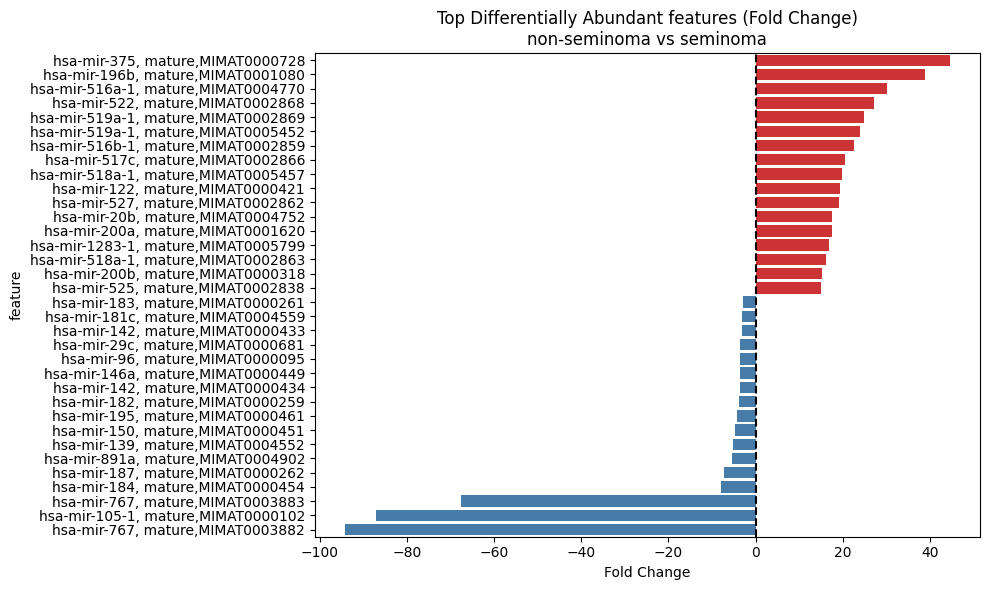

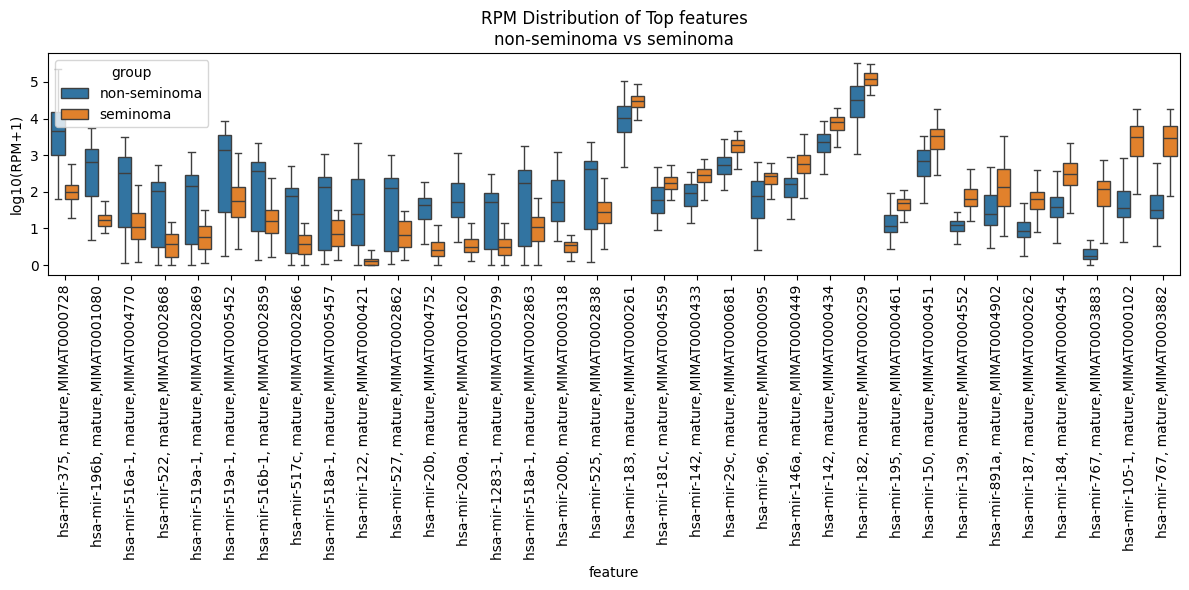

In [ ]:
labels_binary_seminoma = two_class_diagnoses.to_dict()
for sample in labels_binary_seminoma.keys():
  if mdata_2['Seminoma % '][sample] < 100:
    labels_binary_seminoma[sample] = 'mixed sample (unused)'

group_names=["non-seminoma", "seminoma"]
X = feature_filtering_by_class_means(df_to_use, labels_binary_seminoma, group_names[0], group_names[1])
results_seminoma_non_seminoma = plot_differential_features(X, labels_binary_seminoma, group_names=group_names)

In [ ]:
results_seminoma_non_seminoma = reformat_results(results_seminoma_non_seminoma, 'seminoma vs non-seminoma')

In [ ]:
results_seminoma_non_seminoma

,seminoma vs non-seminoma Fold Change,seminoma vs non-seminoma pval,seminoma vs non-seminoma fdr,seminoma vs non-seminoma significant
feature,,,,
"hsa-mir-373, mature,MIMAT0000725",-1.328179,3.963725e-02,5.145070e-02,False
"hsa-mir-365a, mature,MIMAT0000710",-1.274888,6.883386e-04,1.075426e-03,True
"hsa-mir-625, mature,MIMAT0004808",-2.118342,2.207929e-11,4.872164e-10,True
"hsa-mir-200c, mature,MIMAT0000617",6.196792,3.324789e-12,1.000459e-10,True
"hsa-mir-181c, mature,MIMAT0004559",-3.028451,1.239380e-05,2.629710e-05,True
...,...,...,...,...
"hsa-mir-339, mature,MIMAT0000764",1.169526,3.583435e-01,3.953723e-01,False
"hsa-mir-486-1, mature,MIMAT0002177",2.634666,4.175920e-05,7.853576e-05,True
"hsa-mir-96, mature,MIMAT0000095",-3.514162,1.074550e-08,7.354237e-08,True


In [ ]:
experiment_labels_df['seminoma vs non-seminoma'] = labels_binary_seminoma
experiment_results_df = pd.concat([experiment_results_df, results_seminoma_non_seminoma], axis=1)

In [ ]:
experiment_labels_df[0:]

,seminoma vs non-seminoma
TCGA-2G-AAEW-01,seminoma
TCGA-2G-AAEX-01,seminoma
TCGA-2G-AAF1-01,seminoma
TCGA-2G-AAF4-01,seminoma
TCGA-2G-AAF6-01,seminoma
...,...
TCGA-ZM-AA0D-01,seminoma
TCGA-ZM-AA0E-01,seminoma
TCGA-ZM-AA0F-01,seminoma
TCGA-ZM-AA0H-01,seminoma


In [ ]:
experiment_results_df

,seminoma vs non-seminoma Fold Change,seminoma vs non-seminoma pval,seminoma vs non-seminoma fdr,seminoma vs non-seminoma significant
"hsa-let-7a-1, mature,MIMAT0000062",1.016323,0.147996,0.176211,False
"hsa-let-7a-1, mature,MIMAT0004481",NaN,NaN,NaN,NaN
"hsa-let-7a-2, mature,MIMAT0010195",NaN,NaN,NaN,NaN
"hsa-let-7b, mature,MIMAT0000063",-1.195322,0.869566,0.880203,False
"hsa-let-7b, mature,MIMAT0004482",NaN,NaN,NaN,NaN
...,...,...,...,...
"hsa-mir-98, mature,MIMAT0022842",NaN,NaN,NaN,NaN
"hsa-mir-99a, mature,MIMAT0000097",2.974743,0.000019,0.000039,True
"hsa-mir-99a, mature,MIMAT0004511",NaN,NaN,NaN,NaN
"hsa-mir-99b, mature,MIMAT0000689",1.416475,0.000016,0.000034,True


embryonal vs seminoma

number of features expressed above 45 in class embryonal: 284
number of features expressed above 45 in class seminoma: 241
number of features in kept across both classes: 302


<ipython-input-13-8f877c09ea53>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


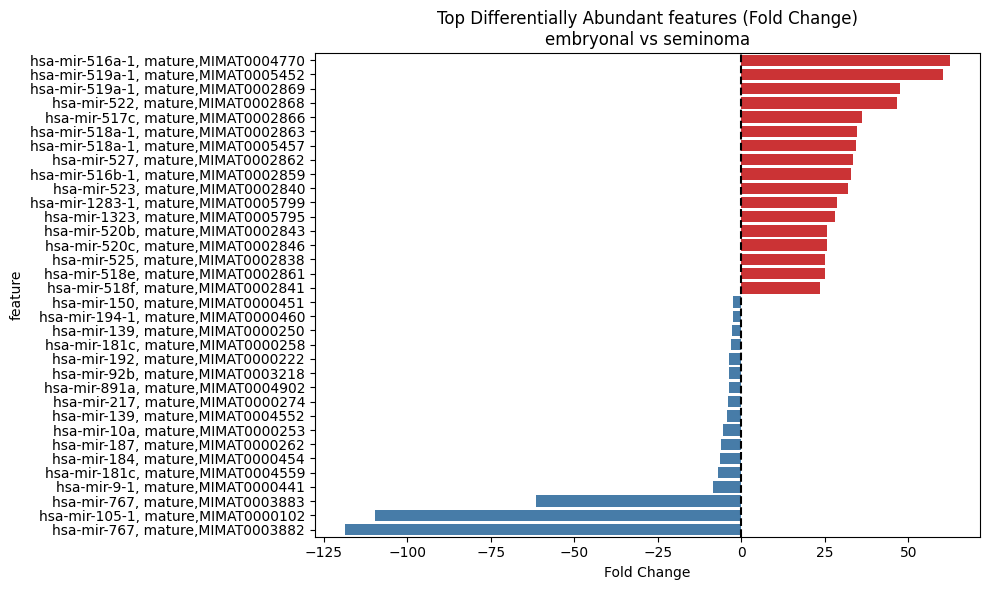

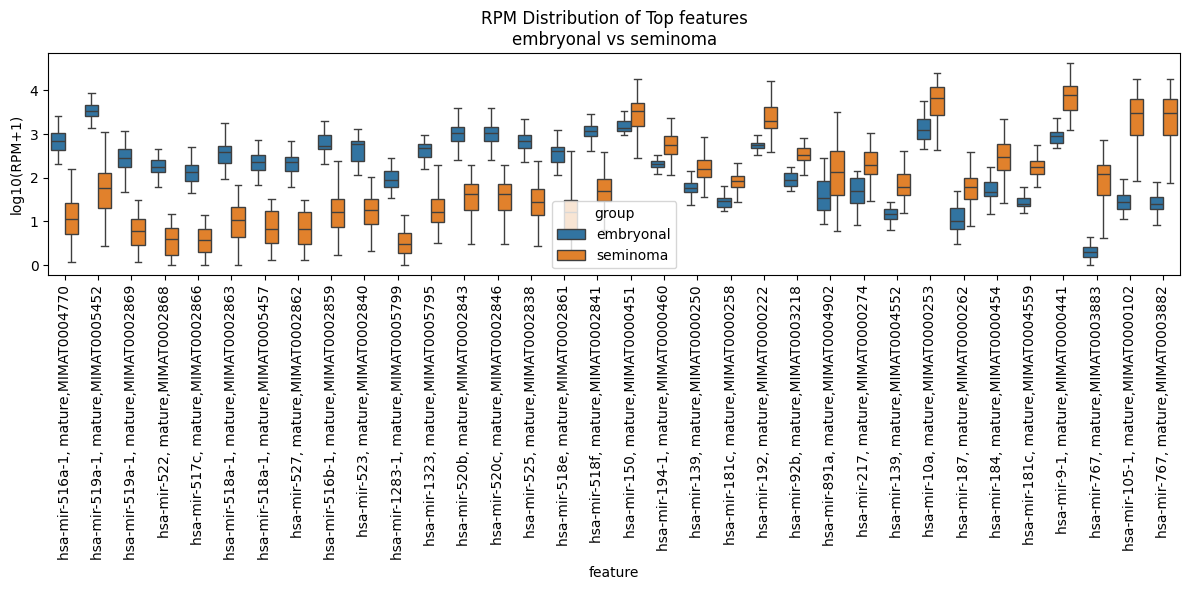

In [ ]:
labels_embryonal_seminoma = diagnoses.to_dict()
for sample in labels_embryonal_seminoma.keys():
  if labels_embryonal_seminoma[sample] != "embryonal" and labels_embryonal_seminoma[sample] != "seminoma":
    labels_embryonal_seminoma[sample] = 'non_embryonal non_seminoma (unused)'

group_names=["embryonal", "seminoma"]
label_dict = labels_embryonal_seminoma
X = feature_filtering_by_class_means(df_to_use, label_dict, group_names[0], group_names[1])
results_embryonal_seminoma = plot_differential_features(X, label_dict, group_names=group_names)

In [ ]:
'''
experiment_labels_df['seminoma vs non-seminoma'] = labels_binary_seminoma
experiment_results_df = pd.concat([experiment_results_df, results_seminoma_non_seminoma], axis=1)
'''
results_embryonal_seminoma = reformat_results(results_embryonal_seminoma, 'embryonal vs seminoma')
experiment_labels_df['embryonal vs seminoma'] = labels_embryonal_seminoma
experiment_results_df = pd.concat([experiment_results_df, results_embryonal_seminoma], axis=1)

In [ ]:
experiment_results_df

,seminoma vs non-seminoma Fold Change,seminoma vs non-seminoma pval,seminoma vs non-seminoma fdr,seminoma vs non-seminoma significant,embryonal vs seminoma Fold Change,embryonal vs seminoma pval,embryonal vs seminoma fdr,embryonal vs seminoma significant
"hsa-let-7a-1, mature,MIMAT0000062",1.016323,0.147996,0.176211,False,1.251202,0.031470,0.053393,False
"hsa-let-7a-1, mature,MIMAT0004481",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"hsa-let-7a-2, mature,MIMAT0010195",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"hsa-let-7b, mature,MIMAT0000063",-1.195322,0.869566,0.880203,False,1.235743,0.121741,0.166361,False
"hsa-let-7b, mature,MIMAT0004482",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
"hsa-mir-98, mature,MIMAT0022842",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"hsa-mir-99a, mature,MIMAT0000097",2.974743,0.000019,0.000039,True,1.434068,0.107384,0.148930,False
"hsa-mir-99a, mature,MIMAT0004511",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"hsa-mir-99b, mature,MIMAT0000689",1.416475,0.000016,0.000034,True,-1.254802,0.006615,0.013408,True


embryonal vs non-embryonal ir non_seminoma

number of features expressed above 45 in class embryonal: 284
number of features expressed above 45 in class non-embryonal non-seminoma: 304
number of features in kept across both classes: 346
number of samples inembryonal: 18
number of samples innon-embryonal non-seminoma: 19


<ipython-input-41-d3ca9d536c1e>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


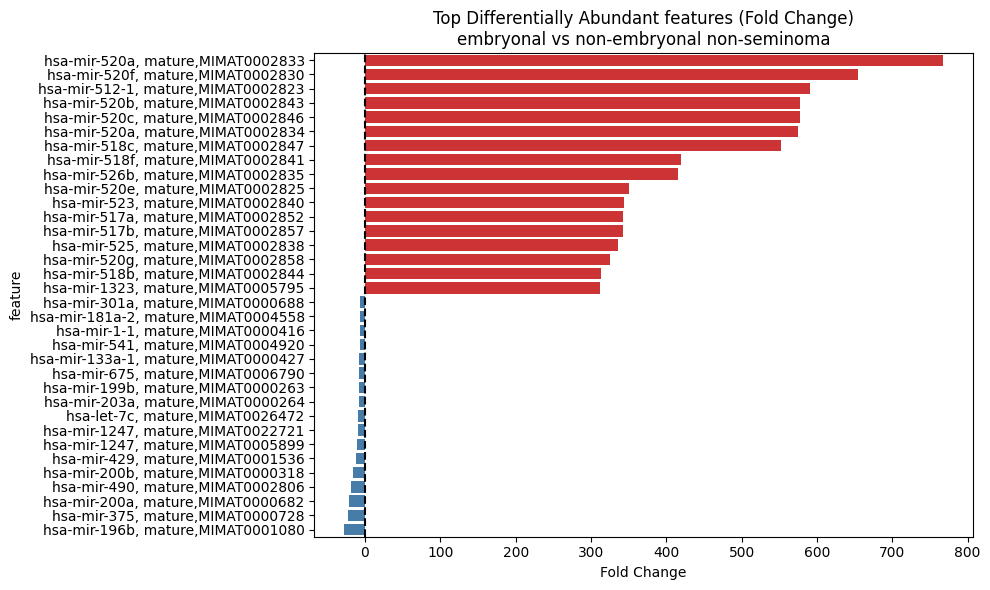

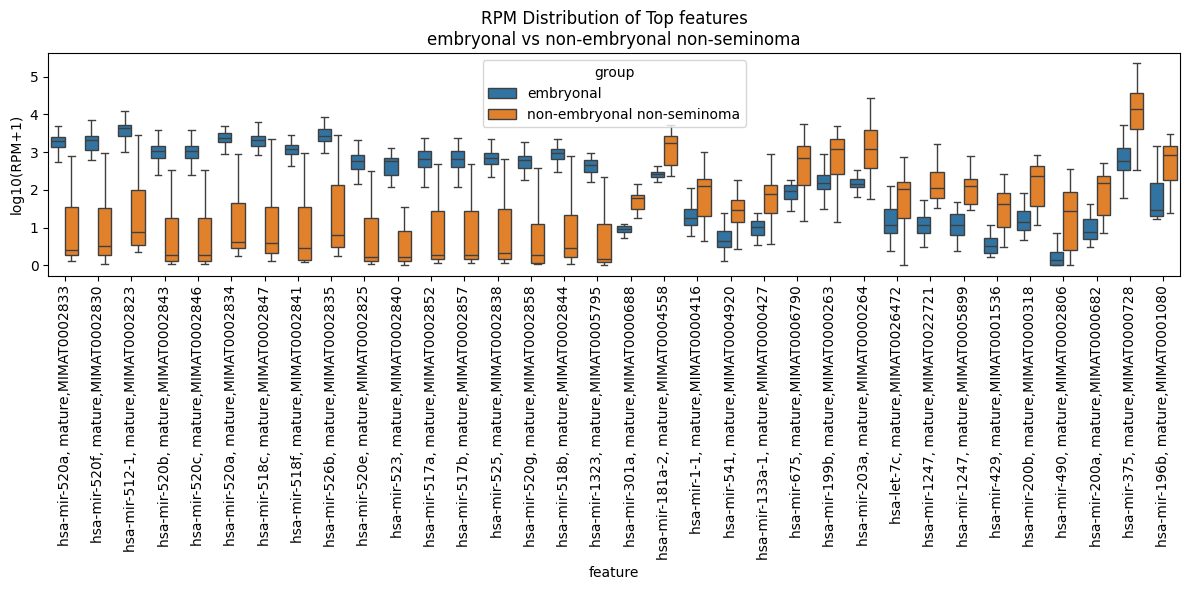

In [ ]:
labels_non_seminoma_non_embryonal = diagnoses.to_dict()
for sample in labels_non_seminoma_non_embryonal.keys():
  if pd.isna(mdata_2['Seminoma % '][sample]) and  pd.isna(mdata_2['Embryonal carcinoma %'][sample]):
    labels_non_seminoma_non_embryonal[sample] = 'non-embryonal non-seminoma'
  elif labels_non_seminoma_non_embryonal[sample] != "embryonal" :
    labels_non_seminoma_non_embryonal[sample] = 'unused'

group_names=["embryonal", "non-embryonal non-seminoma"]
label_dict = labels_non_seminoma_non_embryonal
X = feature_filtering_by_class_means(df_to_use, label_dict, group_names[0], group_names[1])
results_embryonal_non_embryonal = plot_differential_features(X, label_dict, group_names=group_names)

In [ ]:
'''
results_embryonal_non_embryonal = reformat_results(results_embryonal_non_embryonal, 'embryonal vs non_embryonal_non_seminoma')
experiment_labels_df['embryonal vs non_embryonal_non_seminoma'] = labels_results_embryonal_non_embryonal
experiment_results_df = pd.concat([experiment_results_df, results_embryonal_non_embryonal], axis=1)
'''

results_embryonal_non_embryonal = reformat_results(results_embryonal_non_embryonal, 'embryonal vs non_embryonal_non_seminoma')
experiment_labels_df['embryonal vs non_embryonal_non_seminoma'] = labels_non_seminoma_non_embryonal
experiment_results_df = pd.concat([experiment_results_df, results_embryonal_non_embryonal], axis=1)

In [ ]:
experiment_results_df

,seminoma vs non-seminoma Fold Change,seminoma vs non-seminoma pval,seminoma vs non-seminoma fdr,seminoma vs non-seminoma significant,embryonal vs seminoma Fold Change,embryonal vs seminoma pval,embryonal vs seminoma fdr,embryonal vs seminoma significant,embryonal vs non_embryonal_non_seminoma Fold Change,embryonal vs non_embryonal_non_seminoma pval,embryonal vs non_embryonal_non_seminoma fdr,embryonal vs non_embryonal_non_seminoma significant
"hsa-let-7a-1, mature,MIMAT0000062",1.016323,0.147996,0.176211,False,1.251202,0.031470,0.053393,False,1.179961,0.328466,0.386562,False
"hsa-let-7a-1, mature,MIMAT0004481",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"hsa-let-7a-2, mature,MIMAT0010195",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"hsa-let-7b, mature,MIMAT0000063",-1.195322,0.869566,0.880203,False,1.235743,0.121741,0.166361,False,1.540435,0.113442,0.149813,False
"hsa-let-7b, mature,MIMAT0004482",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
"hsa-mir-98, mature,MIMAT0022842",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"hsa-mir-99a, mature,MIMAT0000097",2.974743,0.000019,0.000039,True,1.434068,0.107384,0.148930,False,-4.549685,0.004814,0.010787,True
"hsa-mir-99a, mature,MIMAT0004511",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"hsa-mir-99b, mature,MIMAT0000689",1.416475,0.000016,0.000034,True,-1.254802,0.006615,0.013408,True,-3.283565,0.000003,0.000097,True


In [ ]:
experiment_labels_df[:15]

,seminoma vs non-seminoma,embryonal vs seminoma,embryonal vs non_embryonal_non_seminoma
TCGA-2G-AAEW-01,seminoma,seminoma,unused
TCGA-2G-AAEX-01,seminoma,seminoma,unused
TCGA-2G-AAF1-01,seminoma,seminoma,unused
TCGA-2G-AAF4-01,seminoma,seminoma,unused
TCGA-2G-AAF6-01,seminoma,seminoma,unused
TCGA-2G-AAF8-01,seminoma,seminoma,unused
TCGA-2G-AAFG-01,seminoma,seminoma,unused
TCGA-2G-AAFH-01,seminoma,seminoma,unused
TCGA-2G-AAFI-01,non-seminoma,non_embryonal non_seminoma (unused),unused
TCGA-2G-AAFJ-01,non-seminoma,non_embryonal non_seminoma (unused),non-embryonal non-seminoma


Teratoma vs non-teratoma

number of features expressed above 45 in class teratoma: 276
number of features expressed above 45 in class non-teratoma: 279
number of features in kept across both classes: 336
number of samples in teratoma: 6
number of samples in non-teratoma: 107


<ipython-input-43-9d210b39e07b>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


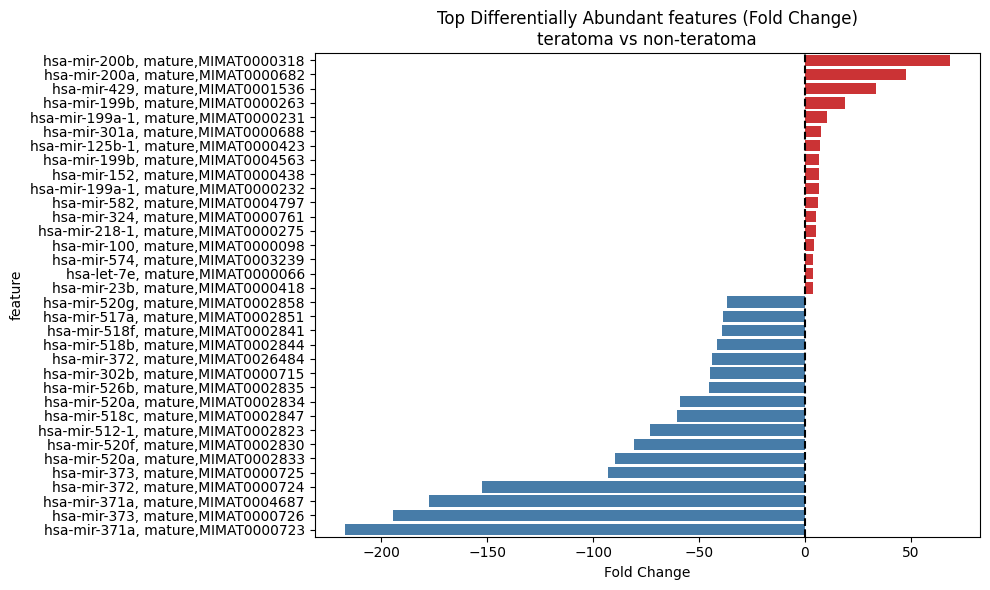

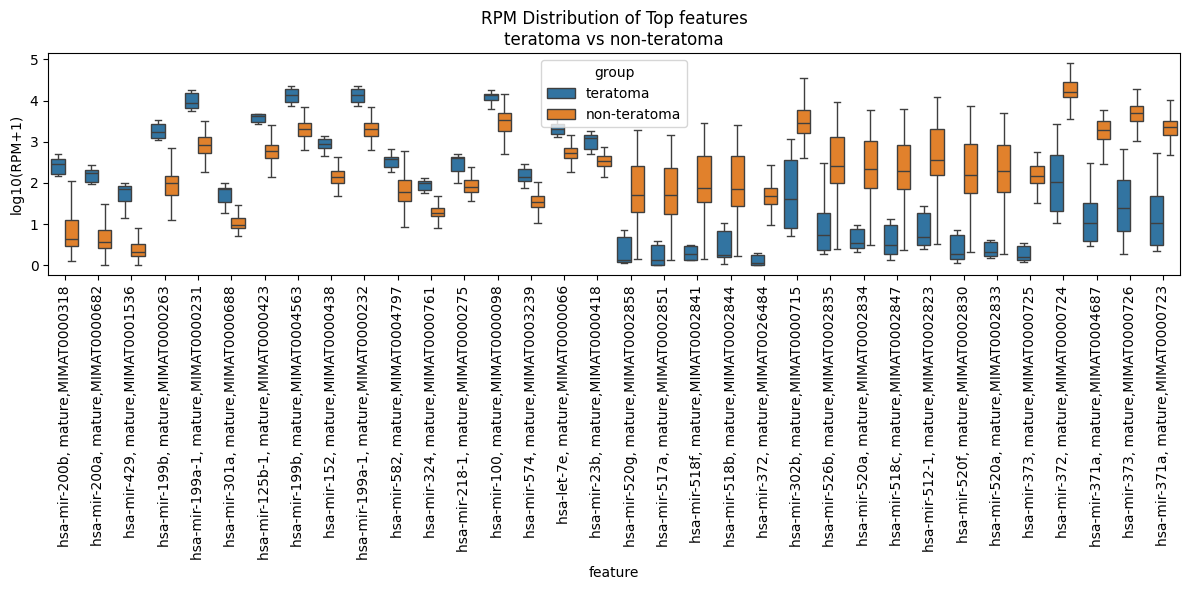

In [ ]:
labels_teratoma = diagnoses.to_dict()
for sample in labels_teratoma.keys():
  if pd.isna(mdata_2['Mature %'][sample]) and  pd.isna(mdata_2['Immature %'][sample]):
    labels_teratoma[sample] = 'non-teratoma'
  elif (mdata_2['Mature %'][sample] == 100 or mdata_2['Immature %'][sample] == 100) or (mdata_2['Mature %'][sample] + mdata_2['Immature %'][sample]) == 100:
    labels_teratoma[sample] = 'teratoma'
  else:
    labels_teratoma[sample] = 'unused'

group_names=["teratoma", "non-teratoma"]
label_dict = labels_teratoma
X = feature_filtering_by_class_means(df_to_use, label_dict, group_names[0], group_names[1])
results_teratoma = plot_differential_features(X, label_dict, group_names=group_names)

In [ ]:
results_teratoma = reformat_results(results_teratoma, 'teratoma vs non-teratoma')
experiment_labels_df['teratoma vs non-teratoma'] = labels_teratoma
experiment_results_df = pd.concat([experiment_results_df, results_teratoma], axis=1)

In [ ]:
experiment_labels_df

,seminoma vs non-seminoma,embryonal vs seminoma,embryonal vs non_embryonal_non_seminoma,teratoma vs non-teratoma
TCGA-2G-AAEW-01,seminoma,seminoma,unused,non-teratoma
TCGA-2G-AAEX-01,seminoma,seminoma,unused,non-teratoma
TCGA-2G-AAF1-01,seminoma,seminoma,unused,non-teratoma
TCGA-2G-AAF4-01,seminoma,seminoma,unused,non-teratoma
TCGA-2G-AAF6-01,seminoma,seminoma,unused,non-teratoma
...,...,...,...,...
TCGA-ZM-AA0D-01,seminoma,seminoma,unused,non-teratoma
TCGA-ZM-AA0E-01,seminoma,seminoma,unused,non-teratoma
TCGA-ZM-AA0F-01,seminoma,seminoma,unused,non-teratoma
TCGA-ZM-AA0H-01,seminoma,seminoma,unused,non-teratoma


Čia kažkas netaip (tos p-values nėra kaip TCGA tyrime, todėl nepriskiriami kai kurie miRNR prie gerai diferencijuojančių - pvz., tas hsa-mir-375) Reiks pasigilinti, ką daryti, kad tai pakeisti. ir pasigilinti į tai kaip tas p-value yra skaičiuojamas.

In [ ]:
results_teratoma.sort_values('teratoma vs non-teratoma Fold Change')[::-1][:15]

,teratoma vs non-teratoma Fold Change,teratoma vs non-teratoma pval,teratoma vs non-teratoma fdr,teratoma vs non-teratoma significant
feature,,,,
"hsa-mir-375, mature,MIMAT0000728",88.793831,0.785303,0.814388,False
"hsa-mir-215, mature,MIMAT0000272",80.991298,0.103181,0.166677,False
"hsa-mir-200b, mature,MIMAT0000318",68.336424,0.018260,0.049062,True
"hsa-mir-490, mature,MIMAT0002806",62.270282,0.075971,0.143407,False
"hsa-mir-200a, mature,MIMAT0000682",47.860000,0.014319,0.040429,True
"hsa-mir-196b, mature,MIMAT0001080",46.542996,0.034238,0.078794,False
"hsa-mir-133a-1, mature,MIMAT0000427",40.368102,0.079550,0.144479,False
"hsa-mir-1-1, mature,MIMAT0000416",36.176628,0.078975,0.144479,False
"hsa-mir-429, mature,MIMAT0001536",33.319042,0.010693,0.032664,True


In [ ]:
label_color_dict = create_label_colors(labels_teratoma)

In [ ]:
label_color_dict = {'embryonal dominant': 'blue',
'non-teratoma': 'cyan',
 'teratoma': 'red',
 'mature teratoma dominant': 'orange',
 'yolk sac dominant': 'purple',
 'non-seminoma- mixed (no dominant component)': 'black'}

In [ ]:
mirna_normalized_isoforms_df['hsa-mir-490, mature,MIMAT0002806'].mean()

np.float64(12.319229671532852)

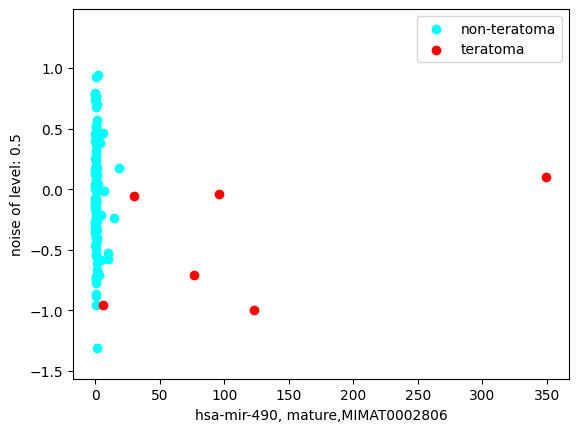

In [ ]:
label_sample_dict = invert_label_dict(labels_teratoma, original_keys = 'samples')

group1_samples = prepare_sample_list(["teratoma"], label_sample_dict=label_sample_dict)
group2_samples = prepare_sample_list(["non-teratoma"], label_sample_dict=label_sample_dict)

plot_single_feature(mirna_normalized_isoforms_df, 'hsa-mir-490, mature,MIMAT0002806', samples_to_use = group1_samples + group2_samples, sample_label_dict= labels_teratoma, noise_level=0.5, label_color_dict = label_color_dict)
#

mutated vs ne mutated seminomos variantai

number of features expressed above 45 in class KIT-mutated seminoma: 219
number of features expressed above 45 in class KIT-Wildtype seminoma: 251
number of features in kept across both classes: 252
number of samples in KIT-mutated seminoma: 25
number of samples in KIT-Wildtype seminoma: 47


<ipython-input-43-9d210b39e07b>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


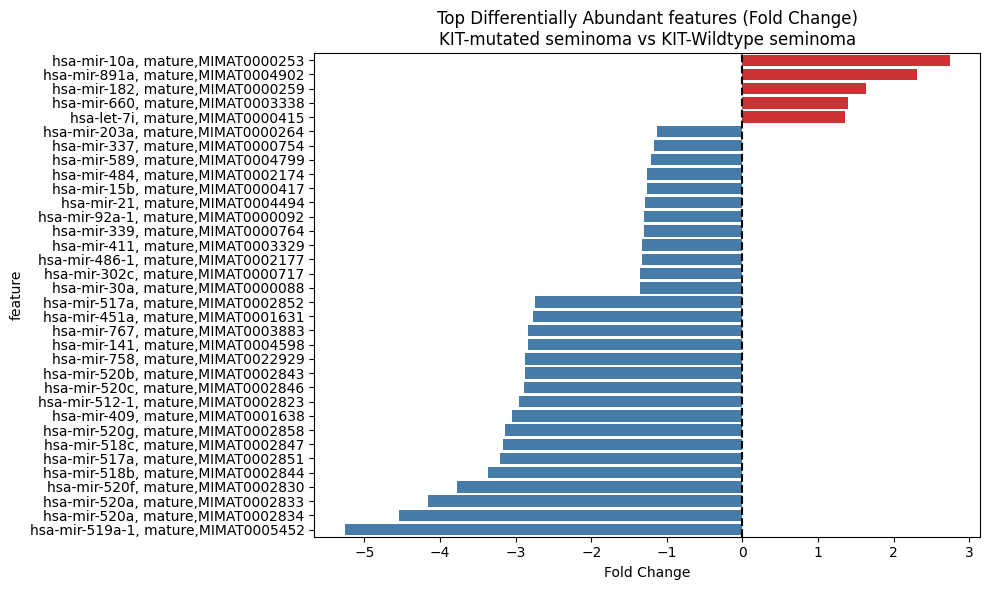

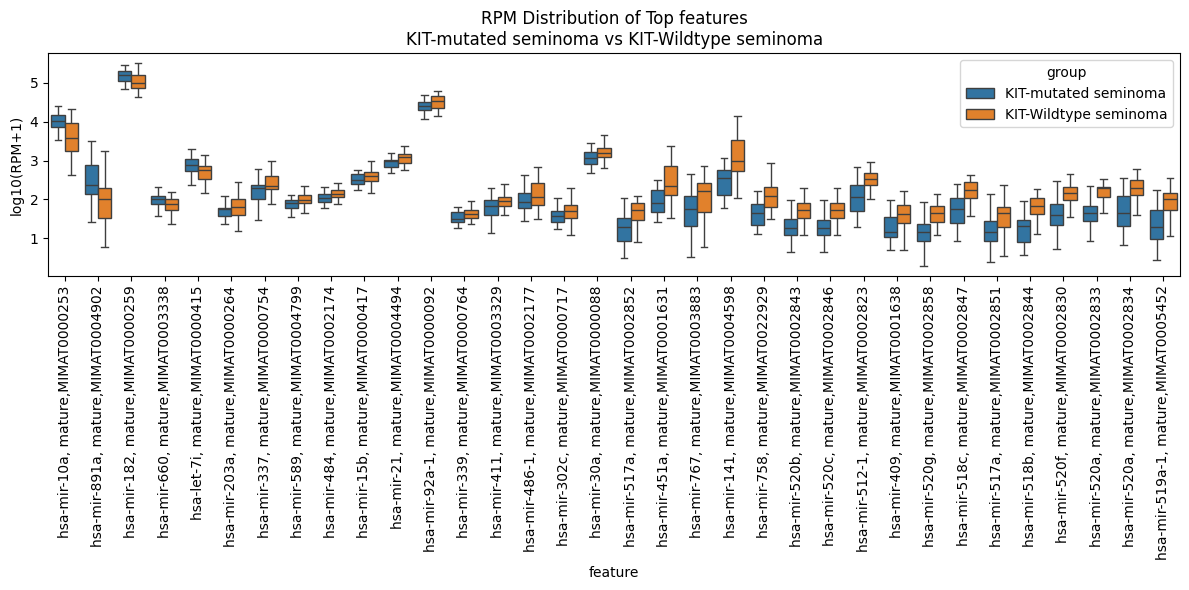

In [ ]:
labels_seminoma_mutated_non_mutated = diagnoses.to_dict()
for sample in labels_seminoma_mutated_non_mutated.keys():
  if labels_seminoma_mutated_non_mutated[sample] == "seminoma" and  mdata_2['KIT'][sample] == 1:
    labels_seminoma_mutated_non_mutated[sample] = 'KIT-mutated seminoma'
  elif labels_seminoma_mutated_non_mutated[sample] == "seminoma" and  mdata_2['KIT'][sample] == 0:
    labels_seminoma_mutated_non_mutated[sample] = 'KIT-Wildtype seminoma'
  else:
    labels_seminoma_mutated_non_mutated[sample] = 'non-seminoma (unused)'

group_names=["KIT-mutated seminoma", "KIT-Wildtype seminoma"]
label_dict = labels_seminoma_mutated_non_mutated
X = feature_filtering_by_class_means(df_to_use, label_dict, group_names[0], group_names[1])
results_mutated_non_mutated = plot_differential_features(X, label_dict, group_names=group_names)

In [ ]:
results_mutated_non_mutated = reformat_results(results_mutated_non_mutated, 'KIT-mutated seminoma vs KIT-wildtype seminoma')
experiment_labels_df['KIT-mutated seminoma vs KIT-wildtype seminoma'] = labels_seminoma_mutated_non_mutated
experiment_results_df = pd.concat([experiment_results_df, results_mutated_non_mutated], axis=1)

In [ ]:
experiment_results_df

,seminoma vs non-seminoma Fold Change,seminoma vs non-seminoma pval,seminoma vs non-seminoma fdr,seminoma vs non-seminoma significant,embryonal vs seminoma Fold Change,embryonal vs seminoma pval,embryonal vs seminoma fdr,embryonal vs seminoma significant,embryonal vs non_embryonal_non_seminoma Fold Change,embryonal vs non_embryonal_non_seminoma pval,embryonal vs non_embryonal_non_seminoma fdr,embryonal vs non_embryonal_non_seminoma significant,teratoma vs non-teratoma Fold Change,teratoma vs non-teratoma pval,teratoma vs non-teratoma fdr,teratoma vs non-teratoma significant,KIT-mutated seminoma vs KIT-wildtype seminoma Fold Change,KIT-mutated seminoma vs KIT-wildtype seminoma pval,KIT-mutated seminoma vs KIT-wildtype seminoma fdr,KIT-mutated seminoma vs KIT-wildtype seminoma significant
"hsa-let-7a-1, mature,MIMAT0000062",1.016323,0.147996,0.176211,False,1.251202,0.031470,0.053393,False,1.179961,0.328466,0.386562,False,1.236411,0.340722,0.413295,False,1.026332,0.476595,0.628805,False
"hsa-let-7a-1, mature,MIMAT0004481",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"hsa-let-7a-2, mature,MIMAT0010195",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"hsa-let-7b, mature,MIMAT0000063",-1.195322,0.869566,0.880203,False,1.235743,0.121741,0.166361,False,1.540435,0.113442,0.149813,False,1.002020,0.667536,0.712038,False,-1.045733,0.861233,0.915741,False
"hsa-let-7b, mature,MIMAT0004482",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"hsa-mir-98, mature,MIMAT0022842",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"hsa-mir-99a, mature,MIMAT0000097",2.974743,0.000019,0.000039,True,1.434068,0.107384,0.148930,False,-4.549685,0.004814,0.010787,True,8.568082,0.030821,0.073446,False,1.056682,0.886261,0.930574,False
"hsa-mir-99a, mature,MIMAT0004511",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"hsa-mir-99b, mature,MIMAT0000689",1.416475,0.000016,0.000034,True,-1.254802,0.006615,0.013408,True,-3.283565,0.000003,0.000097,True,2.410958,0.013427,0.038559,True,-1.357864,0.001741,0.007707,True


In [ ]:
experiment_labels_df

,seminoma vs non-seminoma,embryonal vs seminoma,embryonal vs non_embryonal_non_seminoma,teratoma vs non-teratoma,KIT-mutated seminoma vs KIT-wildtype seminoma
TCGA-2G-AAEW-01,seminoma,seminoma,unused,non-teratoma,KIT-Wildtype seminoma
TCGA-2G-AAEX-01,seminoma,seminoma,unused,non-teratoma,KIT-Wildtype seminoma
TCGA-2G-AAF1-01,seminoma,seminoma,unused,non-teratoma,KIT-mutated seminoma
TCGA-2G-AAF4-01,seminoma,seminoma,unused,non-teratoma,KIT-Wildtype seminoma
TCGA-2G-AAF6-01,seminoma,seminoma,unused,non-teratoma,KIT-Wildtype seminoma
...,...,...,...,...,...
TCGA-ZM-AA0D-01,seminoma,seminoma,unused,non-teratoma,KIT-mutated seminoma
TCGA-ZM-AA0E-01,seminoma,seminoma,unused,non-teratoma,KIT-mutated seminoma
TCGA-ZM-AA0F-01,seminoma,seminoma,unused,non-teratoma,KIT-mutated seminoma
TCGA-ZM-AA0H-01,seminoma,seminoma,unused,non-teratoma,KIT-mutated seminoma


Išsaugom grupių suskaidymus ir rezultatus:

In [ ]:
#save the results and labels
experiment_labels_df.to_csv('TCGA_DE_experiment_suspected_labels.csv', sep = ';')
experiment_results_df.to_csv('TCGA_DE_reproduction_attempt_experiment_results.csv', sep = ';')

In [ ]:
#check if the saved files can be read properly
results = pd.read_csv('TCGA_DE_reproduction_attempt_experiment_results.csv', sep = ';', index_col = 0)
labels = pd.read_csv('TCGA_DE_experiment_suspected_labels.csv', sep = ';', index_col = 0)

In [ ]:
results

,seminoma vs non-seminoma Fold Change,seminoma vs non-seminoma pval,seminoma vs non-seminoma fdr,seminoma vs non-seminoma significant,embryonal vs seminoma Fold Change,embryonal vs seminoma pval,embryonal vs seminoma fdr,embryonal vs seminoma significant,embryonal vs non_embryonal_non_seminoma Fold Change,embryonal vs non_embryonal_non_seminoma pval,embryonal vs non_embryonal_non_seminoma fdr,embryonal vs non_embryonal_non_seminoma significant,teratoma vs non-teratoma Fold Change,teratoma vs non-teratoma pval,teratoma vs non-teratoma fdr,teratoma vs non-teratoma significant,KIT-mutated seminoma vs KIT-wildtype seminoma Fold Change,KIT-mutated seminoma vs KIT-wildtype seminoma pval,KIT-mutated seminoma vs KIT-wildtype seminoma fdr,KIT-mutated seminoma vs KIT-wildtype seminoma significant
"hsa-let-7a-1, mature,MIMAT0000062",1.016323,0.147996,0.176211,False,1.251202,0.031470,0.053393,False,1.179961,0.328466,0.386562,False,1.236411,0.340722,0.413295,False,1.026332,0.476595,0.628805,False
"hsa-let-7a-1, mature,MIMAT0004481",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"hsa-let-7a-2, mature,MIMAT0010195",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"hsa-let-7b, mature,MIMAT0000063",-1.195322,0.869566,0.880203,False,1.235743,0.121741,0.166361,False,1.540435,0.113442,0.149813,False,1.002020,0.667536,0.712038,False,-1.045733,0.861233,0.915741,False
"hsa-let-7b, mature,MIMAT0004482",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"hsa-mir-98, mature,MIMAT0022842",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"hsa-mir-99a, mature,MIMAT0000097",2.974743,0.000019,0.000039,True,1.434068,0.107384,0.148930,False,-4.549685,0.004814,0.010787,True,8.568082,0.030821,0.073446,False,1.056682,0.886261,0.930574,False
"hsa-mir-99a, mature,MIMAT0004511",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"hsa-mir-99b, mature,MIMAT0000689",1.416475,0.000016,0.000034,True,-1.254802,0.006615,0.013408,True,-3.283565,0.000003,0.000097,True,2.410958,0.013427,0.038559,True,-1.357864,0.001741,0.007707,True


In [ ]:
labels

,seminoma vs non-seminoma,embryonal vs seminoma,embryonal vs non_embryonal_non_seminoma,teratoma vs non-teratoma,KIT-mutated seminoma vs KIT-wildtype seminoma
TCGA-2G-AAEW-01,seminoma,seminoma,unused,non-teratoma,KIT-Wildtype seminoma
TCGA-2G-AAEX-01,seminoma,seminoma,unused,non-teratoma,KIT-Wildtype seminoma
TCGA-2G-AAF1-01,seminoma,seminoma,unused,non-teratoma,KIT-mutated seminoma
TCGA-2G-AAF4-01,seminoma,seminoma,unused,non-teratoma,KIT-Wildtype seminoma
TCGA-2G-AAF6-01,seminoma,seminoma,unused,non-teratoma,KIT-Wildtype seminoma
...,...,...,...,...,...
TCGA-ZM-AA0D-01,seminoma,seminoma,unused,non-teratoma,KIT-mutated seminoma
TCGA-ZM-AA0E-01,seminoma,seminoma,unused,non-teratoma,KIT-mutated seminoma
TCGA-ZM-AA0F-01,seminoma,seminoma,unused,non-teratoma,KIT-mutated seminoma
TCGA-ZM-AA0H-01,seminoma,seminoma,unused,non-teratoma,KIT-mutated seminoma
